# 🎓 Fine-Tuning Flan-T5-Base for Educational Slide Generation

Production-grade notebook for training a seq2seq model that generates personalized slide content (titles, bullets, definitions) from textbook chunks tagged with student persona metadata.

---
## Section 1: Environment Setup

In [1]:
# 1a — Install required libraries
!pip install -q transformers[torch] datasets accelerate sentencepiece protobuf
!pip install -q rouge-score bert-score nltk sacrebleu evaluate
!pip install -q matplotlib seaborn pandas tqdm wandb

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 68.2 kB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 105.9 kB/s eta 0:00:00 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 61.4 kB/s eta 0:00:00a 0:00:01


In [2]:
# 1b — Import all dependencies and print versions
import os, sys, json, time, random, warnings, logging, datetime
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import transformers
import datasets
import nltk

nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)

print("=" * 60)
print("DEPENDENCY VERSIONS")
print("=" * 60)
print(f"Python:        {sys.version.split()[0]}")
print(f"PyTorch:       {torch.__version__}")
print(f"Transformers:  {transformers.__version__}")
print(f"Datasets:      {datasets.__version__}")
print(f"NumPy:         {np.__version__}")
print(f"Pandas:        {pd.__version__}")
print()

# GPU detection
if torch.cuda.is_available():
    gpu = torch.cuda.get_device_properties(0)
    print(f"GPU:           {gpu.name}")
    print(f"VRAM:          {gpu.total_memory / 1e9:.1f} GB")
    DEVICE = "cuda"
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    print("GPU:           Apple MPS (Metal)")
    DEVICE = "mps"
else:
    print("GPU:           None (CPU only)")
    DEVICE = "cpu"
print(f"Device:        {DEVICE}")

DEPENDENCY VERSIONS
Python:        3.12.13
PyTorch:       2.10.0+cu128
Transformers:  5.0.0
Datasets:      4.0.0
NumPy:         2.0.2
Pandas:        2.2.2

GPU:           Tesla T4
VRAM:          15.6 GB
Device:        cuda


In [4]:
# 1c — Central Configuration (ALL tunable parameters live here)
class CFG:
    # Model
    model_name       = "google/flan-t5-large"
    
    # ============ TEST MODE ============
    # Set to True to do a quick dry-run with tiny data & 1 epoch
    # Set to False for full production training
    test_mode        = False
    # ===================================
    
    # Dataset
    dataset_path     = "/content/content_train.jsonl"  # <-- SET THIS
    test_size        = 0.10
    val_size         = 0.10
    
    # Tokenization
    max_input_len    = 512
    max_target_len   = 256
    
    # Training
    epochs           = 5
    batch_size       = 4
    gradient_accumulation_steps = 4
    learning_rate    = 1e-3
    weight_decay     = 0.0
    warmup_steps     = 200
    lr_scheduler     = "constant"
    
    # Checkpointing
    save_steps       = 500
    eval_steps       = 500
    save_total_limit = 3
    early_stopping_patience = 3
    
    # Directories
    output_dir       = Path("models/content_specialist")
    checkpoint_dir   = Path("models/content_specialist/checkpoints")
    results_dir      = Path("results/content_specialist")
    
    # Reproducibility
    seed             = 42
    
    # WandB (optional)
    use_wandb        = False
    wandb_project    = "slide-content-finetuning"

# Create directories
for d in [CFG.output_dir, CFG.checkpoint_dir, CFG.results_dir]:
    d.mkdir(parents=True, exist_ok=True)

# Set all seeds
random.seed(CFG.seed)
np.random.seed(CFG.seed)
torch.manual_seed(CFG.seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(CFG.seed)

# Apply test mode overrides
if CFG.test_mode:
    CFG.epochs           = 1
    CFG.batch_size       = 1
    CFG.gradient_accumulation_steps = 1
    CFG.warmup_steps     = 5
    CFG.save_steps       = 20
    CFG.eval_steps       = 20
    CFG.early_stopping_patience = 1
    print("⚡ TEST MODE ON — 1 epoch, tiny batch, fast eval")
else:
    print("🚀 PRODUCTION MODE — full training")

print("✅ Configuration set. All directories created.")
print(f"   Model:       {CFG.model_name}")
print(f"   Dataset:     {CFG.dataset_path}")
print(f"   Epochs:      {CFG.epochs}")
print(f"   Batch size:  {CFG.batch_size} (effective: {CFG.batch_size * CFG.gradient_accumulation_steps})")
print(f"   LR:          {CFG.learning_rate}")
print(f"   Seed:        {CFG.seed}")

🚀 PRODUCTION MODE — full training
✅ Configuration set. All directories created.
   Model:       google/flan-t5-large
   Dataset:     /content/content_train.jsonl
   Epochs:      5
   Batch size:  4 (effective: 16)
   LR:          0.001
   Seed:        42


---
## Section 2: Data Loading and Exploration
Load the JSONL dataset, inspect samples, and analyze token distributions.

In [5]:
# 2a — Load the JSONL dataset
raw_data = []
malformed = 0
with open(CFG.dataset_path, "r") as f:
    for i, line in enumerate(f):
        line = line.strip()
        if not line:
            continue
        try:
            obj = json.loads(line)
            if "input" in obj and "target" in obj and obj["input"].strip() and obj["target"].strip():
                raw_data.append(obj)
            else:
                malformed += 1
        except json.JSONDecodeError:
            malformed += 1

print(f"Total valid examples:    {len(raw_data)}")
print(f"Malformed/empty lines:   {malformed}")

# Trim data in test mode
if CFG.test_mode:
    raw_data = raw_data[:100]
    print(f"⚡ TEST MODE: trimmed to {len(raw_data)} examples")


Total valid examples:    19316
Malformed/empty lines:   0


In [6]:
# 2b — Display sample examples
for i in range(min(3, len(raw_data))):
    print(f"\n{'='*70}")
    print(f"EXAMPLE {i+1}")
    print(f"{'='*70}")
    print(f"INPUT ({len(raw_data[i]['input'])} chars):")
    print(raw_data[i]["input"][:300] + "..." if len(raw_data[i]["input"]) > 300 else raw_data[i]["input"])
    print(f"\nTARGET ({len(raw_data[i]['target'])} chars):")
    print(raw_data[i]["target"][:300] + "..." if len(raw_data[i]["target"]) > 300 else raw_data[i]["target"])


EXAMPLE 1
INPUT (1032 chars):
[MASTERY: Novice] [MODE: Visual_Heavy] [LANG: Elementary]
Context: CHAPTER
ONE
INTRODUCTION
1.1Objectives
•To review the ideas of computer science, programming, and problem-solving.
•To understand abstraction and the role it plays in the problem-solving process.
•To understand and implement the noti...

TARGET (316 chars):
TITLE: Abstraction and Abstract Data Types Overview
DEFINE [Abstraction]: A way to hide details and focus on the important idea, like using a map instead of the whole world.
DEFINE [Abstract Data Type]: A description of a data structure that lists what operations it supports, without explaining how ...

EXAMPLE 2
INPUT (1028 chars):
[MASTERY: Expert] [MODE: Text_Heavy] [LANG: Advanced]
Context: CHAPTER
ONE
INTRODUCTION
1.1Objectives
•To review the ideas of computer science, programming, and problem-solving.
•To understand abstraction and the role it plays in the problem-solving process.
•To understand and implement the notion o...

TARG

In [7]:
# 2c — Statistical analysis of character lengths
input_lens  = [len(d["input"]) for d in raw_data]
target_lens = [len(d["target"]) for d in raw_data]

def print_stats(name, lengths):
    arr = np.array(lengths)
    print(f"\n{name}:")
    print(f"  Mean:   {arr.mean():.0f}  |  Median: {np.median(arr):.0f}")
    print(f"  Min:    {arr.min():.0f}  |  Max:    {arr.max():.0f}")
    print(f"  P25:    {np.percentile(arr, 25):.0f}  |  P75:    {np.percentile(arr, 75):.0f}")
    print(f"  P90:    {np.percentile(arr, 90):.0f}  |  P95:    {np.percentile(arr, 95):.0f}")
    print(f"  P99:    {np.percentile(arr, 99):.0f}")

print_stats("INPUT character lengths", input_lens)
print_stats("TARGET character lengths", target_lens)


INPUT character lengths:
  Mean:   1031  |  Median: 1037
  Min:    224  |  Max:    1074
  P25:    1015  |  P75:    1054
  P90:    1061  |  P95:    1064
  P99:    1069

TARGET character lengths:
  Mean:   566  |  Median: 530
  Min:    187  |  Max:    1507
  P25:    380  |  P75:    745
  P90:    870  |  P95:    928
  P99:    1043


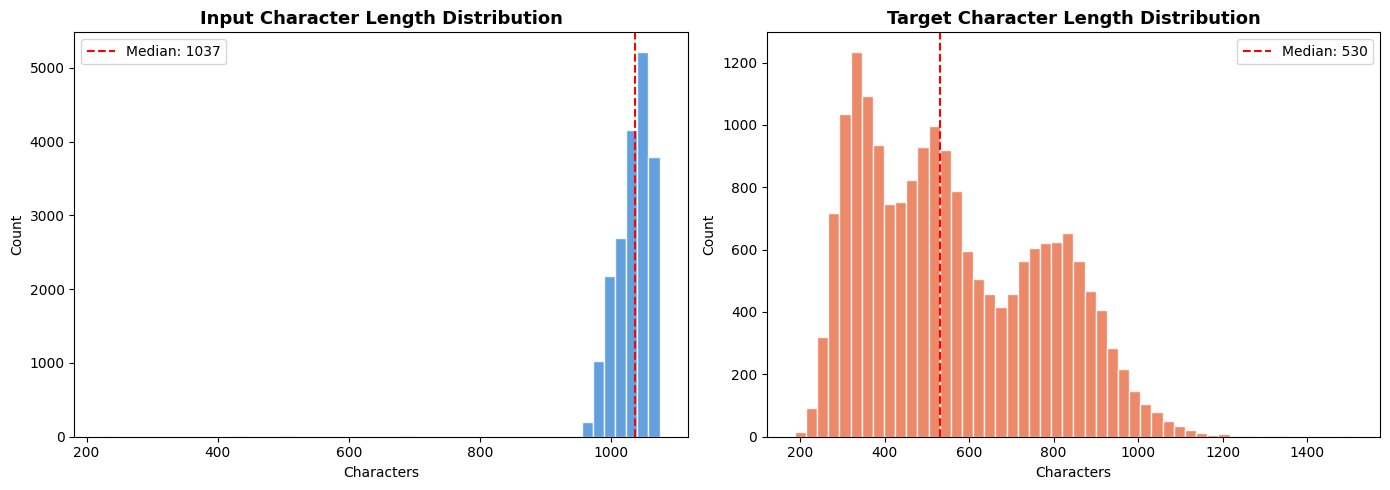

Saved to results/content_specialist/char_length_distributions.png


In [8]:
# 2d — Visualize character length distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(input_lens, bins=50, color="#4A90D9", edgecolor="white", alpha=0.85)
axes[0].axvline(np.median(input_lens), color="red", linestyle="--", label=f"Median: {np.median(input_lens):.0f}")
axes[0].set_title("Input Character Length Distribution", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Characters")
axes[0].set_ylabel("Count")
axes[0].legend()

axes[1].hist(target_lens, bins=50, color="#E8744F", edgecolor="white", alpha=0.85)
axes[1].axvline(np.median(target_lens), color="red", linestyle="--", label=f"Median: {np.median(target_lens):.0f}")
axes[1].set_title("Target Character Length Distribution", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Characters")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.tight_layout()
plt.savefig(CFG.results_dir / "char_length_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved to {CFG.results_dir / 'char_length_distributions.png'}")

In [9]:
# 2e — Train / Validation / Test split
from sklearn.model_selection import train_test_split

train_val, test_data = train_test_split(raw_data, test_size=CFG.test_size, random_state=CFG.seed)
train_data, val_data = train_test_split(train_val, test_size=CFG.val_size / (1 - CFG.test_size), random_state=CFG.seed)

print(f"Train: {len(train_data):,}  |  Val: {len(val_data):,}  |  Test: {len(test_data):,}")
print(f"Total: {len(train_data) + len(val_data) + len(test_data):,}")

Train: 15,452  |  Val: 1,932  |  Test: 1,932
Total: 19,316


---
## Section 3: Tokenization and Preprocessing
Load the Flan-T5 tokenizer, tokenize all splits, and verify truncation statistics.

In [10]:
# 3a — Load tokenizer
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(CFG.model_name)
print(f"Tokenizer: {CFG.model_name}")
print(f"Vocab size: {tokenizer.vocab_size:,}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

Tokenizer: google/flan-t5-large
Vocab size: 32,100


In [11]:
# 3b — Analyze token lengths BEFORE truncation
from tqdm import tqdm

def get_token_lengths(data, desc=""):
    input_toks, target_toks = [], []
    for ex in tqdm(data, desc=desc, leave=False):
        input_toks.append(len(tokenizer.encode(ex["input"], add_special_tokens=True)))
        target_toks.append(len(tokenizer.encode(ex["target"], add_special_tokens=True)))
    return input_toks, target_toks

train_input_toks, train_target_toks = get_token_lengths(train_data, "Tokenizing train")

print_stats("TRAIN input token lengths", train_input_toks)
print_stats("TRAIN target token lengths", train_target_toks)

input_exceed  = sum(1 for t in train_input_toks if t > CFG.max_input_len)
target_exceed = sum(1 for t in train_target_toks if t > CFG.max_target_len)
print(f"\n⚠️  Inputs exceeding {CFG.max_input_len} tokens:  {input_exceed} ({100*input_exceed/len(train_input_toks):.1f}%)")
print(f"⚠️  Targets exceeding {CFG.max_target_len} tokens: {target_exceed} ({100*target_exceed/len(train_target_toks):.1f}%)")

Tokenizing train:   0%|          | 73/15452 [00:00<00:21, 725.28it/s]Token indices sequence length is longer than the specified maximum sequence length for this model (521 > 512). Running this sequence through the model will result in indexing errors
                                                                         


TRAIN input token lengths:
  Mean:   340  |  Median: 324
  Min:    83  |  Max:    645
  P25:    278  |  P75:    391
  P90:    456  |  P95:    486
  P99:    542

TRAIN target token lengths:
  Mean:   152  |  Median: 142
  Min:    50  |  Max:    386
  P25:    104  |  P75:    197
  P90:    230  |  P95:    247
  P99:    280

⚠️  Inputs exceeding 512 tokens:  336 (2.2%)
⚠️  Targets exceeding 256 tokens: 474 (3.1%)


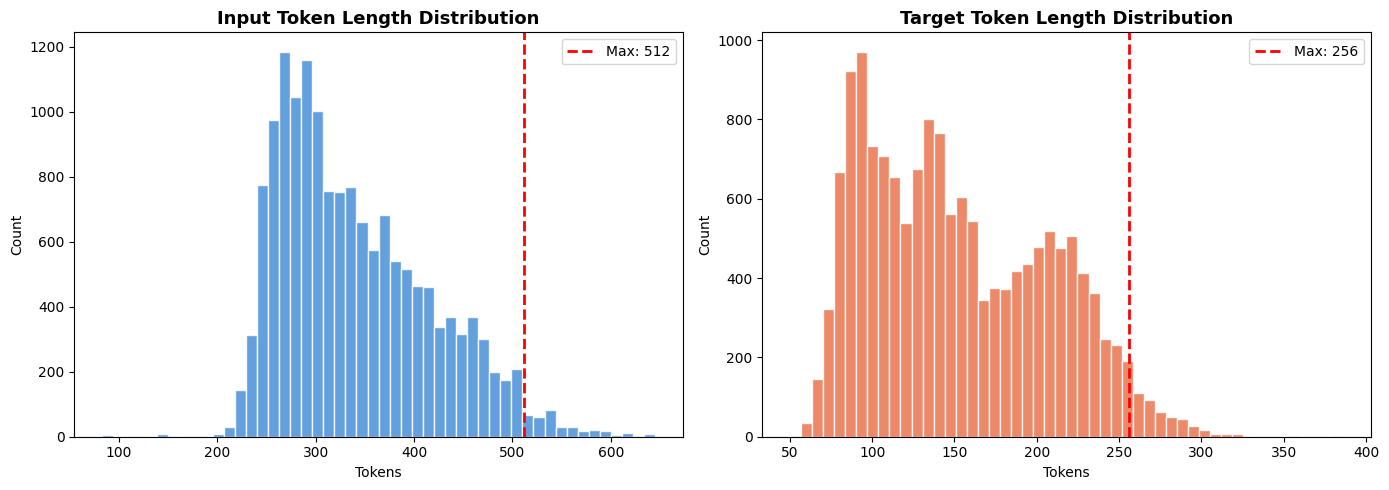

In [12]:
# 3c — Visualize token length distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(train_input_toks, bins=50, color="#4A90D9", edgecolor="white", alpha=0.85)
axes[0].axvline(CFG.max_input_len, color="red", linestyle="--", linewidth=2, label=f"Max: {CFG.max_input_len}")
axes[0].set_title("Input Token Length Distribution", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Tokens"); axes[0].set_ylabel("Count"); axes[0].legend()

axes[1].hist(train_target_toks, bins=50, color="#E8744F", edgecolor="white", alpha=0.85)
axes[1].axvline(CFG.max_target_len, color="red", linestyle="--", linewidth=2, label=f"Max: {CFG.max_target_len}")
axes[1].set_title("Target Token Length Distribution", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Tokens"); axes[1].set_ylabel("Count"); axes[1].legend()

plt.tight_layout()
plt.savefig(CFG.results_dir / "token_length_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

In [13]:
# 3d — Build HuggingFace Datasets and tokenize
from datasets import Dataset

def make_hf_dataset(data_list):
    return Dataset.from_dict({
        "input": [d["input"] for d in data_list],
        "target": [d["target"] for d in data_list],
    })

ds_train = make_hf_dataset(train_data)
ds_val   = make_hf_dataset(val_data)
ds_test  = make_hf_dataset(test_data)

def tokenize_fn(batch):
    model_inputs = tokenizer(
        batch["input"],
        max_length=CFG.max_input_len,
        truncation=True,
        padding="max_length",
    )
    labels = tokenizer(
        batch["target"],
        max_length=CFG.max_target_len,
        truncation=True,
        padding="max_length",
    )
    # Replace pad token ids in labels with -100 so they are ignored by loss
    label_ids = labels["input_ids"]
    label_ids = [
        [(tok if tok != tokenizer.pad_token_id else -100) for tok in seq]
        for seq in label_ids
    ]
    model_inputs["labels"] = label_ids
    return model_inputs

tok_train = ds_train.map(tokenize_fn, batched=True, batch_size=256, remove_columns=ds_train.column_names, desc="Tokenizing train")
tok_val   = ds_val.map(tokenize_fn, batched=True, batch_size=256, remove_columns=ds_val.column_names, desc="Tokenizing val")
tok_test  = ds_test.map(tokenize_fn, batched=True, batch_size=256, remove_columns=ds_test.column_names, desc="Tokenizing test")

tok_train.set_format("torch")
tok_val.set_format("torch")
tok_test.set_format("torch")

print(f"✅ Tokenized — Train: {len(tok_train):,}  Val: {len(tok_val):,}  Test: {len(tok_test):,}")

Tokenizing train:   0%|          | 0/15452 [00:00<?, ? examples/s]

Tokenizing val:   0%|          | 0/1932 [00:00<?, ? examples/s]

Tokenizing test:   0%|          | 0/1932 [00:00<?, ? examples/s]

✅ Tokenized — Train: 15,452  Val: 1,932  Test: 1,932


---
## Section 4: Model Setup
Load the Flan-T5-large model and inspect its architecture.

In [14]:
# 4a — Load model
from transformers import AutoModelForSeq2SeqLM

model = AutoModelForSeq2SeqLM.from_pretrained(CFG.model_name)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Model:             {CFG.model_name}")
print(f"Total params:      {total_params:,}")
print(f"Trainable params:  {trainable_params:,}")
print(f"Model size:        ~{total_params * 4 / 1e9:.2f} GB (fp32)")

if DEVICE == "cuda":
    model = model.to(DEVICE)
    alloc = torch.cuda.memory_allocated() / 1e9
    print(f"GPU memory after model load: {alloc:.2f} GB")

# Enable gradient checkpointing to save ~40% activation memory
model.gradient_checkpointing_enable()
print("✅ Gradient checkpointing enabled (saves ~40% activation memory)")


model.safetensors:   0%|          | 0.00/3.13G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/558 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Model:             google/flan-t5-large
Total params:      783,150,080
Trainable params:  783,150,080
Model size:        ~3.13 GB (fp32)
GPU memory after model load: 3.28 GB


---
## Section 5: Training
Configure and run fine-tuning with HuggingFace Seq2SeqTrainer.
Features: mixed precision, gradient accumulation, early stopping, checkpoint resume.

In [15]:
# 5a — Optional WandB setup
if CFG.use_wandb:
    try:
        import wandb
        wandb.init(project=CFG.wandb_project, config=vars(CFG))
        report_to = "wandb"
        print("✅ WandB initialized")
    except Exception as e:
        print(f"⚠️ WandB unavailable ({e}), falling back to local logging")
        report_to = "none"
else:
    report_to = "none"
    print("ℹ️  WandB disabled, using local logging only")

ℹ️  WandB disabled, using local logging only


In [16]:
# 5b — Define compute_metrics for evaluation during training
from transformers import Seq2SeqTrainingArguments, Seq2SeqTrainer, EarlyStoppingCallback
import evaluate

rouge_metric = evaluate.load("rouge")

# Fixed samples for qualitative inspection each epoch
QUAL_INDICES = list(range(min(5, len(ds_val))))
qual_inputs  = [ds_val[i]["input"] for i in QUAL_INDICES]
qual_refs    = [ds_val[i]["target"] for i in QUAL_INDICES]

def compute_metrics(eval_preds):
    preds, labels = eval_preds
    # Decode predictions
    if isinstance(preds, tuple):
        preds = preds[0]
    # Replace -100 in labels
    preds = np.where(preds != -100, preds, tokenizer.pad_token_id)
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_preds  = tokenizer.batch_decode(preds, skip_special_tokens=True)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)
    
    # ROUGE
    rouge_result = rouge_metric.compute(
        predictions=decoded_preds, references=decoded_labels, use_stemmer=True
    )
    
    # Average output length
    avg_pred_len = np.mean([len(p.split()) for p in decoded_preds])
    avg_ref_len  = np.mean([len(r.split()) for r in decoded_labels])
    
    return {
        "rouge1":        round(rouge_result["rouge1"], 4),
        "rouge2":        round(rouge_result["rouge2"], 4),
        "rougeL":        round(rouge_result["rougeL"], 4),
        "avg_pred_len":  round(avg_pred_len, 1),
        "avg_ref_len":   round(avg_ref_len, 1),
    }

print("✅ Metrics function defined (ROUGE-1, ROUGE-2, ROUGE-L, avg lengths)")

✅ Metrics function defined (ROUGE-1, ROUGE-2, ROUGE-L, avg lengths)


In [17]:
# 5c — Training arguments
fp16_available = torch.cuda.is_available()

training_args = Seq2SeqTrainingArguments(
    output_dir=str(CFG.checkpoint_dir),
    optim="adafactor",
    gradient_checkpointing=True,
    num_train_epochs=CFG.epochs,
    per_device_train_batch_size=CFG.batch_size,
    per_device_eval_batch_size=CFG.batch_size,
    gradient_accumulation_steps=CFG.gradient_accumulation_steps,
    learning_rate=CFG.learning_rate,
    warmup_steps=CFG.warmup_steps,
    lr_scheduler_type=CFG.lr_scheduler,
    fp16=fp16_available,
    predict_with_generate=True,
    generation_max_length=CFG.max_target_len,
    eval_strategy="steps",
    eval_steps=CFG.eval_steps,
    save_strategy="steps",
    save_steps=CFG.save_steps,
    save_total_limit=CFG.save_total_limit,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    logging_dir=str(CFG.results_dir / "logs"),
    logging_steps=50,
    report_to=report_to,
    seed=CFG.seed,
    dataloader_num_workers=2,
    remove_unused_columns=True,
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tok_train,
    eval_dataset=tok_val,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=CFG.early_stopping_patience)],
)

print("✅ Trainer configured")
print(f"   Effective batch size: {CFG.batch_size * CFG.gradient_accumulation_steps}")
print(f"   FP16: {fp16_available}")
print(f"   Eval every {CFG.eval_steps} steps, save every {CFG.save_steps} steps")
print(f"   Early stopping patience: {CFG.early_stopping_patience}")

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


✅ Trainer configured
   Effective batch size: 16
   FP16: True
   Eval every 500 steps, save every 500 steps
   Early stopping patience: 3


In [18]:
# 5d — Train (with checkpoint resume support)
train_start = time.time()

# Check for existing checkpoints to resume from
resume_ckpt = None
if CFG.checkpoint_dir.exists():
    ckpts = sorted(CFG.checkpoint_dir.glob("checkpoint-*"), key=os.path.getmtime)
    if ckpts:
        resume_ckpt = str(ckpts[-1])
        print(f"📂 Resuming from checkpoint: {resume_ckpt}")

train_result = trainer.train(resume_from_checkpoint=resume_ckpt)

train_time = time.time() - train_start
print(f"\n✅ Training complete in {train_time/60:.1f} minutes")
print(f"   Final train loss: {train_result.metrics.get('train_loss', 'N/A')}")

OutOfMemoryError: CUDA out of memory. Tried to allocate 32.00 MiB. GPU 0 has a total capacity of 14.56 GiB of which 7.81 MiB is free. Including non-PyTorch memory, this process has 14.55 GiB memory in use. Of the allocated memory 14.40 GiB is allocated by PyTorch, and 26.18 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

---
## Section 6: Metrics and Evaluation
Comprehensive evaluation with ROUGE, BERTScore, BLEU, Perplexity, Distinct-N, and qualitative samples.

In [18]:
# 6a — Plot training curves from trainer log history
log_history = trainer.state.log_history

train_losses = [(e["step"], e["loss"]) for e in log_history if "loss" in e and "eval_loss" not in e]
eval_entries = [e for e in log_history if "eval_loss" in e]
eval_losses  = [(e["step"], e["eval_loss"]) for e in eval_entries]

fig, ax = plt.subplots(figsize=(12, 5))
if train_losses:
    ax.plot(*zip(*train_losses), label="Train Loss", alpha=0.7, color="#4A90D9")
if eval_losses:
    ax.plot(*zip(*eval_losses), label="Val Loss", marker="o", color="#E8744F", linewidth=2)
ax.set_xlabel("Step"); ax.set_ylabel("Loss")
ax.set_title("Training & Validation Loss", fontsize=14, fontweight="bold")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(CFG.results_dir / "loss_curves.png", dpi=150, bbox_inches="tight")
plt.show()

# Plot ROUGE curves
if eval_entries and "eval_rouge1" in eval_entries[0]:
    fig, ax = plt.subplots(figsize=(12, 5))
    for metric_key, color in [("eval_rouge1", "#4A90D9"), ("eval_rouge2", "#E8744F"), ("eval_rougeL", "#50C878")]:
        vals = [(e["step"], e[metric_key]) for e in eval_entries if metric_key in e]
        if vals:
            ax.plot(*zip(*vals), label=metric_key.replace("eval_", "").upper(), marker="o", linewidth=2, color=color)
    ax.set_xlabel("Step"); ax.set_ylabel("Score")
    ax.set_title("ROUGE Scores During Training", fontsize=14, fontweight="bold")
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(CFG.results_dir / "rouge_curves.png", dpi=150, bbox_inches="tight")
    plt.show()

In [19]:
# 6b — Generate predictions on validation set for detailed metrics
print("Generating predictions on validation set...")
val_preds = trainer.predict(tok_val, max_length=CFG.max_target_len)
val_labels = np.where(val_preds.label_ids != -100, val_preds.label_ids, tokenizer.pad_token_id)
decoded_preds  = tokenizer.batch_decode(val_preds.predictions, skip_special_tokens=True)
decoded_labels = tokenizer.batch_decode(val_labels, skip_special_tokens=True)
print(f"Generated {len(decoded_preds)} predictions")

In [20]:
# 6c — ROUGE scores
rouge_results = rouge_metric.compute(predictions=decoded_preds, references=decoded_labels, use_stemmer=True)
print("ROUGE Scores:")
for k, v in rouge_results.items():
    print(f"  {k}: {v:.4f}")

In [21]:
# 6d — BERTScore
from bert_score import score as bert_score_fn

print("Computing BERTScore (this may take a minute)...")
P, R, F1 = bert_score_fn(decoded_preds, decoded_labels, lang="en", verbose=False, device=DEVICE)
bert_p, bert_r, bert_f1 = P.mean().item(), R.mean().item(), F1.mean().item()
print(f"BERTScore — P: {bert_p:.4f}  R: {bert_r:.4f}  F1: {bert_f1:.4f}")

In [22]:
# 6e — BLEU
from sacrebleu.metrics import BLEU

bleu = BLEU()
bleu_result = bleu.corpus_score(decoded_preds, [decoded_labels])
print(f"BLEU: {bleu_result.score:.2f}")

In [23]:
# 6f — Perplexity (on validation set)
val_eval = trainer.evaluate(tok_val)
perplexity = np.exp(val_eval["eval_loss"])
print(f"Validation Loss: {val_eval['eval_loss']:.4f}")
print(f"Perplexity:      {perplexity:.2f}")

In [24]:
# 6g — Distinct-1 and Distinct-2 (lexical diversity)
def compute_distinct_n(texts, n):
    all_ngrams = []
    for text in texts:
        tokens = text.lower().split()
        ngrams = [tuple(tokens[i:i+n]) for i in range(len(tokens)-n+1)]
        all_ngrams.extend(ngrams)
    if not all_ngrams:
        return 0.0
    return len(set(all_ngrams)) / len(all_ngrams)

distinct_1 = compute_distinct_n(decoded_preds, 1)
distinct_2 = compute_distinct_n(decoded_preds, 2)
print(f"Distinct-1: {distinct_1:.4f}")
print(f"Distinct-2: {distinct_2:.4f}")

In [25]:
# 6h — Average output length comparison
avg_pred_words = np.mean([len(p.split()) for p in decoded_preds])
avg_ref_words  = np.mean([len(r.split()) for r in decoded_labels])
print(f"Avg prediction length: {avg_pred_words:.1f} words")
print(f"Avg reference length:  {avg_ref_words:.1f} words")
print(f"Length ratio:          {avg_pred_words/avg_ref_words:.2f}")

In [ ]:
# 6i — Qualitative evaluation: 5 fixed validation samples
print("=" * 80)
print("QUALITATIVE SAMPLES")
print("=" * 80)

# Generate fresh predictions for the fixed qualitative samples
for i, (inp, ref) in enumerate(zip(qual_inputs, qual_refs)):
    enc = tokenizer(inp, return_tensors="pt", max_length=CFG.max_input_len, truncation=True, padding=True)
    enc = {k: v.to(model.device) for k, v in enc.items()}
    with torch.no_grad():
        out = model.generate(**enc, max_length=CFG.max_target_len, num_beams=4, early_stopping=True)
    pred = tokenizer.decode(out[0], skip_special_tokens=True)
    
    print(f"\n{'─'*70}")
    print(f"Sample {i+1}")
    print(f"{'─'*70}")
    print(f"INPUT:      {inp[:200]}...")
    print(f"\nREFERENCE:  {ref[:300]}")
    print(f"\nGENERATED:  {pred[:300]}")

---
## Section 7: Checkpoint Management
List all saved checkpoints and identify the best one.

In [ ]:
# 7a — Display checkpoint inventory
print("=" * 70)
print("CHECKPOINT INVENTORY")
print("=" * 70)

ckpt_dir = CFG.checkpoint_dir
ckpts = sorted(ckpt_dir.glob("checkpoint-*"), key=lambda p: int(p.name.split("-")[1]))

for ckpt in ckpts:
    trainer_state_path = ckpt / "trainer_state.json"
    info = ""
    if trainer_state_path.exists():
        with open(trainer_state_path) as f:
            state = json.load(f)
        step = state.get("global_step", "?")
        epoch = state.get("epoch", "?")
        # Find eval loss for this step
        best_metric = state.get("best_metric", None)
        info = f"Step: {step}, Epoch: {epoch:.2f}" if isinstance(epoch, float) else f"Step: {step}, Epoch: {epoch}"
        if best_metric is not None:
            info += f", Best val loss: {best_metric:.4f}"
    
    size_mb = sum(f.stat().st_size for f in ckpt.rglob("*") if f.is_file()) / 1e6
    print(f"  📁 {ckpt.name:25s} | {size_mb:7.1f} MB | {info}")

print(f"\nBest model loaded: {trainer.state.best_model_checkpoint}")

In [ ]:
# 7b — Checkpoint loading utility
def load_from_checkpoint(checkpoint_path):
    """Load model and tokenizer from a checkpoint for inference or resumed training."""
    loaded_model = AutoModelForSeq2SeqLM.from_pretrained(checkpoint_path)
    loaded_tokenizer = AutoTokenizer.from_pretrained(checkpoint_path)
    print(f"✅ Loaded model from {checkpoint_path}")
    return loaded_model, loaded_tokenizer

# Example: load_from_checkpoint("models/content_specialist/checkpoints/checkpoint-1000")

# Enable gradient checkpointing to save ~40% activation memory
model.gradient_checkpointing_enable()
print("✅ Gradient checkpointing enabled (saves ~40% activation memory)")


---
## Section 8: Final Model Saving
Save the best model, tokenizer, and a model card with full training metadata.

In [ ]:
# 8a — Save best model and tokenizer
final_path = CFG.output_dir / "final"
final_path.mkdir(parents=True, exist_ok=True)

trainer.save_model(str(final_path))
tokenizer.save_pretrained(str(final_path))
print(f"✅ Model saved to {final_path}")

# 8b — Save model card with all metadata
model_card = {
    "model_name": CFG.model_name,
    "task": "educational_slide_content_generation",
    "dataset": str(CFG.dataset_path),
    "dataset_stats": {
        "total_examples": len(raw_data),
        "train_size": len(train_data),
        "val_size": len(val_data),
        "test_size": len(test_data),
    },
    "hyperparameters": {
        "epochs": CFG.epochs,
        "batch_size": CFG.batch_size,
        "effective_batch_size": CFG.batch_size * CFG.gradient_accumulation_steps,
        "learning_rate": CFG.learning_rate,
        "weight_decay": CFG.weight_decay,
        "warmup_steps": CFG.warmup_steps,
        "lr_scheduler": CFG.lr_scheduler,
        "max_input_len": CFG.max_input_len,
        "max_target_len": CFG.max_target_len,
        "gradient_accumulation_steps": CFG.gradient_accumulation_steps,
        "seed": CFG.seed,
    },
    "final_metrics": {
        "val_loss": val_eval["eval_loss"],
        "perplexity": float(perplexity),
        "rouge1": rouge_results["rouge1"],
        "rouge2": rouge_results["rouge2"],
        "rougeL": rouge_results["rougeL"],
        "bertscore_f1": bert_f1,
        "bleu": bleu_result.score,
        "distinct_1": distinct_1,
        "distinct_2": distinct_2,
    },
    "training_time_minutes": round(train_time / 60, 1),
    "best_checkpoint": trainer.state.best_model_checkpoint,
    "trained_at": datetime.datetime.now().isoformat(),
}

card_path = final_path / "model_card.json"
with open(card_path, "w") as f:
    json.dump(model_card, f, indent=2)
print(f"✅ Model card saved to {card_path}")

---
## Section 9: Inference Testing
Load the saved model and evaluate on the held-out test set.

In [ ]:
# 9a — Clean inference function
def generate_slide_content(text, persona_mastery="Intermediate", persona_mode="Balanced", 
                           persona_lang="Native", loaded_model=None, loaded_tokenizer=None):
    """Generate slide bullets from raw text + persona tags."""
    mdl = loaded_model or model
    tok = loaded_tokenizer or tokenizer
    
    input_text = f"[MASTERY: {persona_mastery}] [MODE: {persona_mode}] [LANG: {persona_lang}]\nContext: {text}"
    enc = tok(input_text, return_tensors="pt", max_length=CFG.max_input_len, truncation=True, padding=True)
    enc = {k: v.to(mdl.device) for k, v in enc.items()}
    
    with torch.no_grad():
        out = mdl.generate(
            **enc,
            max_length=CFG.max_target_len,
            num_beams=4,
            early_stopping=True,
            no_repeat_ngram_size=3,
        )
    return tok.decode(out[0], skip_special_tokens=True)

# Quick test
result = generate_slide_content("Binary search is an efficient algorithm for finding an item in a sorted list.")
print("Quick inference test:")
print(result)

In [ ]:
# 9b — Evaluate on 10 test samples
print("=" * 80)
print("TEST SET SAMPLES (10 examples)")
print("=" * 80)

test_preds_sample = []
for i in range(min(10, len(test_data))):
    ex = test_data[i]
    enc = tokenizer(ex["input"], return_tensors="pt", max_length=CFG.max_input_len, truncation=True, padding=True)
    enc = {k: v.to(model.device) for k, v in enc.items()}
    with torch.no_grad():
        out = model.generate(**enc, max_length=CFG.max_target_len, num_beams=4, early_stopping=True)
    pred = tokenizer.decode(out[0], skip_special_tokens=True)
    test_preds_sample.append(pred)
    
    print(f"\n{'━'*70}")
    print(f"Test Sample {i+1}")
    print(f"{'━'*70}")
    print(f"INPUT:      {ex['input'][:200]}...")
    print(f"\nREFERENCE:  {ex['target'][:300]}")
    print(f"\nGENERATED:  {pred[:300]}")

In [ ]:
# 9c — Full test set evaluation
print("\nRunning full test set evaluation...")
test_preds_obj = trainer.predict(tok_test, max_length=CFG.max_target_len)
test_labels = np.where(test_preds_obj.label_ids != -100, test_preds_obj.label_ids, tokenizer.pad_token_id)
test_decoded_preds  = tokenizer.batch_decode(test_preds_obj.predictions, skip_special_tokens=True)
test_decoded_labels = tokenizer.batch_decode(test_labels, skip_special_tokens=True)

# ROUGE
test_rouge = rouge_metric.compute(predictions=test_decoded_preds, references=test_decoded_labels, use_stemmer=True)
# BERTScore
test_P, test_R, test_F1 = bert_score_fn(test_decoded_preds, test_decoded_labels, lang="en", verbose=False, device=DEVICE)
# BLEU
test_bleu = bleu.corpus_score(test_decoded_preds, [test_decoded_labels])
# Distinct-N
test_d1 = compute_distinct_n(test_decoded_preds, 1)
test_d2 = compute_distinct_n(test_decoded_preds, 2)

print("\n" + "=" * 50)
print("  FINAL TEST SET METRICS")
print("=" * 50)
test_metrics = {
    "ROUGE-1": test_rouge["rouge1"],
    "ROUGE-2": test_rouge["rouge2"],
    "ROUGE-L": test_rouge["rougeL"],
    "BERTScore F1": test_F1.mean().item(),
    "BLEU": test_bleu.score,
    "Distinct-1": test_d1,
    "Distinct-2": test_d2,
    "Test Loss": test_preds_obj.metrics.get("test_loss", "N/A"),
}
for k, v in test_metrics.items():
    print(f"  {k:20s}: {v:.4f}" if isinstance(v, float) else f"  {k:20s}: {v}")

---
## Section 10: Full Training Summary
Comprehensive overview of training results, best/worst examples, and resource usage.

In [ ]:
# 10a — Summary dashboard
print("=" * 70)
print("  📊 COMPLETE TRAINING SUMMARY")
print("=" * 70)
print(f"  Model:                {CFG.model_name}")
print(f"  Dataset:              {len(raw_data):,} examples")
print(f"  Training time:        {train_time/60:.1f} minutes")
print(f"  Best val loss:        {trainer.state.best_metric:.4f}")
print(f"  Best checkpoint:      {trainer.state.best_model_checkpoint}")
print()
print("  TEST SET SCORES:")
for k, v in test_metrics.items():
    print(f"    {k:20s}: {v:.4f}" if isinstance(v, float) else f"    {k:20s}: {v}")

if DEVICE == "cuda":
    print(f"\n  Peak GPU memory:      {torch.cuda.max_memory_allocated() / 1e9:.2f} GB")

In [ ]:
# 10b — Best and worst 3 examples by BERTScore
f1_scores = test_F1.tolist()
indices_sorted = np.argsort(f1_scores)

print("\n" + "=" * 70)
print("  🏆 TOP 3 BEST EXAMPLES (by BERTScore F1)")
print("=" * 70)
for rank, idx in enumerate(indices_sorted[-3:][::-1], 1):
    print(f"\n  #{rank} (F1: {f1_scores[idx]:.4f})")
    print(f"  REF: {test_decoded_labels[idx][:200]}")
    print(f"  GEN: {test_decoded_preds[idx][:200]}")

print("\n" + "=" * 70)
print("  ⚠️  BOTTOM 3 WORST EXAMPLES (by BERTScore F1)")
print("=" * 70)
for rank, idx in enumerate(indices_sorted[:3], 1):
    print(f"\n  #{rank} (F1: {f1_scores[idx]:.4f})")
    print(f"  REF: {test_decoded_labels[idx][:200]}")
    print(f"  GEN: {test_decoded_preds[idx][:200]}")

In [ ]:
# 10c — Save final summary plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss curves
if train_losses:
    axes[0].plot(*zip(*train_losses), label="Train", alpha=0.7, color="#4A90D9")
if eval_losses:
    axes[0].plot(*zip(*eval_losses), label="Val", marker="o", color="#E8744F")
axes[0].set_title("Loss Curves", fontweight="bold")
axes[0].set_xlabel("Step"); axes[0].set_ylabel("Loss"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Metric bars
metric_names = ["ROUGE-1", "ROUGE-2", "ROUGE-L", "BERTScore\nF1", "Distinct-1", "Distinct-2"]
metric_vals  = [test_rouge["rouge1"], test_rouge["rouge2"], test_rouge["rougeL"], 
                test_F1.mean().item(), test_d1, test_d2]
colors = ["#4A90D9", "#5B9BD5", "#50C878", "#E8744F", "#9B59B6", "#F39C12"]
axes[1].bar(metric_names, metric_vals, color=colors, edgecolor="white")
axes[1].set_title("Test Metrics", fontweight="bold")
axes[1].set_ylim(0, 1); axes[1].grid(True, alpha=0.3, axis="y")
for i, v in enumerate(metric_vals):
    axes[1].text(i, v + 0.02, f"{v:.3f}", ha="center", fontsize=9)

# BERTScore distribution
axes[2].hist(f1_scores, bins=40, color="#E8744F", edgecolor="white", alpha=0.85)
axes[2].axvline(np.mean(f1_scores), color="red", linestyle="--", label=f"Mean: {np.mean(f1_scores):.3f}")
axes[2].set_title("BERTScore F1 Distribution", fontweight="bold")
axes[2].set_xlabel("F1"); axes[2].set_ylabel("Count"); axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(CFG.results_dir / "training_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\n✅ All results saved to {CFG.results_dir}/")
print("🎉 Training pipeline complete!")